# Quadratic Forms: The $\mathbf{x}^T \mathbf{W} \mathbf{x}$ Pattern

The **quadratic form** "sandwiches" a matrix between a vector and its transpose:

$$q(\mathbf{x}) = \mathbf{x}^T \mathbf{W} \mathbf{x} = \sum_{i} \sum_{j} W_{ij} x_i x_j$$

This takes a vector and returns a **scalar**. It's one of the most important patterns in machine learning!

### Where It Appears
- **Mahalanobis distance**: $d^2 = (\mathbf{x} - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})$
- **Gaussian exponent**: $\exp(-\frac{1}{2}\mathbf{x}^T\mathbf{\Sigma}^{-1}\mathbf{x})$
- **Portfolio variance**: $\sigma_p^2 = \mathbf{w}^T \mathbf{\Sigma} \mathbf{w}$
- **Neural network loss**: $\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

---
## 1. Computing a Quadratic Form

Let's break down what $\mathbf{x}^T \mathbf{W} \mathbf{x}$ computes.

In [15]:
# Simple example
x = np.array([2, 3])
W = np.array([[4, 1], 
              [1, 2]])

# Compute step by step
Wx = W @ x              # First: matrix-vector product
q = x @ Wx              # Then: dot product (same as x.T @ Wx)

print(f"x = {x}")
print(f"W = \n{W}")
print(f"\nStep 1: W @ x = {Wx}")
print(f"Step 2: x · (W @ x) = {x} · {Wx} = {q}")
print(f"\nResult: x.T @ W @ x = {q}")

x = [2 3]
W = 
[[4 1]
 [1 2]]

Step 1: W @ x = [11  8]
Step 2: x · (W @ x) = [2 3] · [11  8] = 46

Result: x.T @ W @ x = 46


In [16]:
# Expand the formula
print("Expanded form:")
print(f"x.T @ W @ x = W[0,0]·x[0]² + W[1,1]·x[1]² + (W[0,1]+W[1,0])·x[0]·x[1]")
print(f"            = {W[0,0]}·{x[0]}² + {W[1,1]}·{x[1]}² + ({W[0,1]}+{W[1,0]})·{x[0]}·{x[1]}")
print(f"            = {W[0,0]*x[0]**2} + {W[1,1]*x[1]**2} + {(W[0,1]+W[1,0])*x[0]*x[1]}")
print(f"            = {W[0,0]*x[0]**2 + W[1,1]*x[1]**2 + (W[0,1]+W[1,0])*x[0]*x[1]}")

Expanded form:
x.T @ W @ x = W[0,0]·x[0]² + W[1,1]·x[1]² + (W[0,1]+W[1,0])·x[0]·x[1]
            = 4·2² + 2·3² + (1+1)·2·3
            = 16 + 18 + 12
            = 46


---
## 2. Geometric Interpretation: Weighted Distance

The quadratic form measures a **weighted, possibly skewed, distance** from the origin.

- When $\mathbf{W} = \mathbf{I}$ (identity): $\mathbf{x}^T \mathbf{I} \mathbf{x} = \|\mathbf{x}\|^2$ (Euclidean distance squared)
- When $\mathbf{W} = \mathbf{\Sigma}^{-1}$ (precision matrix): we get **Mahalanobis distance**

In [17]:
# Compare Euclidean vs Mahalanobis distance
Sigma = np.array([[2, 1.2], 
                  [1.2, 1]])  # Covariance (correlated)
Sigma_inv = np.linalg.inv(Sigma)  # Precision matrix

# Create a grid of points
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)

# Compute distances for each point
euclidean_dist = X**2 + Y**2  # x.T @ I @ x

# Mahalanobis: x.T @ Sigma_inv @ x
mahalanobis_dist = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        v = np.array([X[i,j], Y[i,j]])
        mahalanobis_dist[i,j] = v @ Sigma_inv @ v

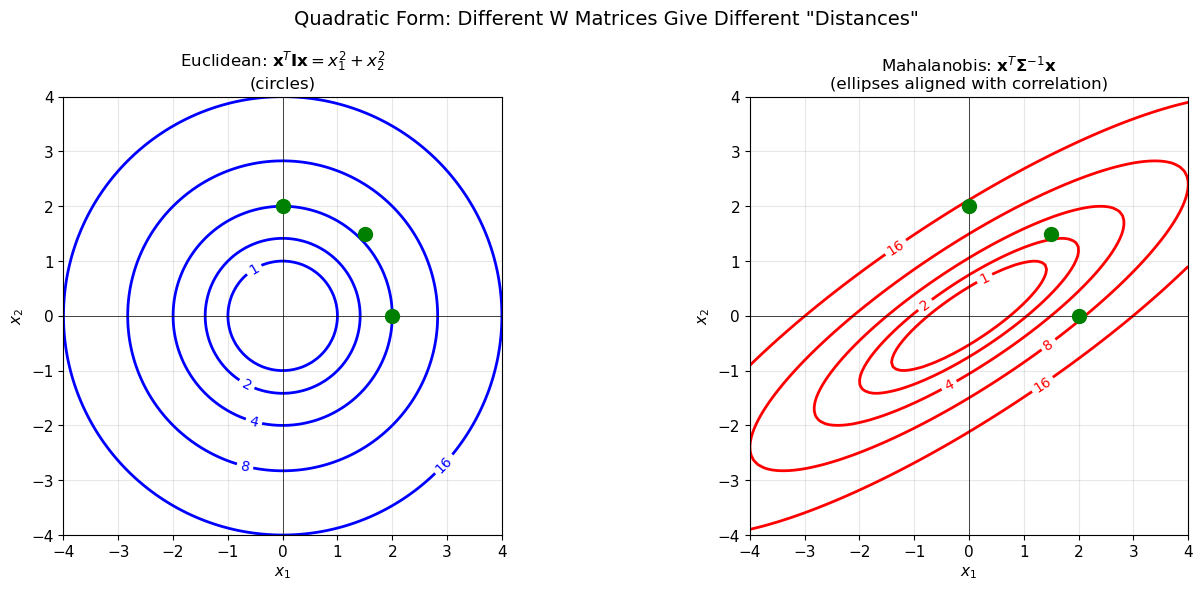


Covariance Σ (used for Mahalanobis):
[[2.  1.2]
 [1.2 1. ]]


In [18]:
# Visualize as contour plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

levels = [1, 2, 4, 8, 16]

# Euclidean
ax1 = axes[0]
cs1 = ax1.contour(X, Y, euclidean_dist, levels=levels, colors='blue', linewidths=2)
ax1.clabel(cs1, inline=True, fontsize=10, fmt='%.0f')
ax1.set_title('Euclidean: $\\mathbf{x}^T \\mathbf{I} \\mathbf{x} = x_1^2 + x_2^2$\n(circles)', fontsize=12)
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.axvline(x=0, color='black', linewidth=0.5)

# Mahalanobis
ax2 = axes[1]
cs2 = ax2.contour(X, Y, mahalanobis_dist, levels=levels, colors='red', linewidths=2)
ax2.clabel(cs2, inline=True, fontsize=10, fmt='%.0f')
ax2.set_title('Mahalanobis: $\\mathbf{x}^T \\mathbf{\\Sigma}^{-1} \\mathbf{x}$\n(ellipses aligned with correlation)', fontsize=12)
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.axvline(x=0, color='black', linewidth=0.5)

# Add some sample points
points = [np.array([2, 0]), np.array([0, 2]), np.array([1.5, 1.5])]
for pt in points:
    euc = pt @ pt
    mah = pt @ Sigma_inv @ pt
    ax1.scatter([pt[0]], [pt[1]], c='green', s=100, zorder=5)
    ax2.scatter([pt[0]], [pt[1]], c='green', s=100, zorder=5)

plt.suptitle('Quadratic Form: Different W Matrices Give Different "Distances"', fontsize=14)
plt.tight_layout()
plt.show()

print("\nCovariance Σ (used for Mahalanobis):")
print(Sigma)

---
## Real-World Scenario: Outlier Detection

**Scenario**: You're monitoring sensor data from a machine. "Normal" readings cluster around a mean with correlated noise. An **outlier** is a reading that's statistically far from normal.

Using Euclidean distance fails because it ignores correlations. **Mahalanobis distance** (a quadratic form!) correctly identifies outliers.

In [19]:
# Generate normal sensor readings (correlated)
np.random.seed(42)
n_normal = 200
mean = np.array([50, 30])  # Normal: temperature ~50°C, vibration ~30 Hz
cov = np.array([[25, 15],   # Temperature variance and correlation
                [15, 16]])  # Vibration variance

normal_data = np.random.multivariate_normal(mean, cov, n_normal)

# Add some outliers
outliers = np.array([
    [65, 30],   # High temperature (along correlation)
    [50, 45],   # High vibration
    [60, 40],   # Both high but along correlation - less suspicious!
    [55, 20],   # Unusual combo - temp up, vibration down (suspicious)
])

print("Sensor Monitoring for Machine Health")
print("="*50)
print(f"Normal operating mean: Temperature={mean[0]}°C, Vibration={mean[1]}Hz")
print(f"Covariance matrix (temp and vibration are positively correlated):")
print(cov)

Sensor Monitoring for Machine Health
Normal operating mean: Temperature=50°C, Vibration=30Hz
Covariance matrix (temp and vibration are positively correlated):
[[25 15]
 [15 16]]


In [20]:
# Compute distances for outliers
cov_inv = np.linalg.inv(cov)

print("\nOutlier Analysis (comparing distance measures)")
print("="*60)
print(f"{'Point':20} {'Euclidean':>12} {'Mahalanobis':>12} {'Verdict':>15}")
print("-"*60)

for i, pt in enumerate(outliers):
    centered = pt - mean
    euc_dist = np.sqrt(centered @ centered)
    mah_dist = np.sqrt(centered @ cov_inv @ centered)
    
    # Mahalanobis > 2 is roughly 5% significance level for 2D
    if mah_dist > 3:
        verdict = "OUTLIER!"
    elif mah_dist > 2:
        verdict = "Suspicious"
    else:
        verdict = "Normal"
    
    print(f"({pt[0]:3.0f}°C, {pt[1]:3.0f}Hz){' '*5} {euc_dist:>10.2f}   {mah_dist:>10.2f}   {verdict:>15}")


Outlier Analysis (comparing distance measures)
Point                   Euclidean  Mahalanobis         Verdict
------------------------------------------------------------
( 65°C,  30Hz)           15.00         4.54          OUTLIER!
( 50°C,  45Hz)           15.00         5.67          OUTLIER!
( 60°C,  40Hz)           14.14         2.51        Suspicious
( 55°C,  20Hz)           11.18         5.01          OUTLIER!


In [ ]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_covariance_ellipse(ax, mean, cov, n_std=2, **kwargs):
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(mean, width, height, angle=angle, fill=False, **kwargs)
    ax.add_patch(ellipse)

for ax, title in zip(axes, ['Euclidean View (ignores correlation)', 'Mahalanobis View (accounts for correlation)']):
    # Plot normal data
    ax.scatter(normal_data[:, 0], normal_data[:, 1], alpha=0.3, s=30, c='blue', label='Normal')
    
    # Plot outliers
    ax.scatter(outliers[:, 0], outliers[:, 1], c='red', s=100, marker='X', 
               edgecolors='black', linewidth=1.5, label='Test points', zorder=5)
    
    # Label outliers
    for i, pt in enumerate(outliers):
        ax.annotate(f'{i+1}', (pt[0]+1, pt[1]+1), fontsize=10, fontweight='bold')
    
    ax.scatter([mean[0]], [mean[1]], c='green', s=150, marker='*', label='Mean', zorder=5)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Vibration (Hz)')
    ax.set_title(title, fontsize=11)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

# Left: Euclidean circles
for r in [5, 10, 15, 20]:
    circle = plt.Circle(mean, r, fill=False, color='gray', linestyle='--', alpha=0.5)
    axes[0].add_patch(circle)

# Right: Mahalanobis ellipses
for n_std in [1, 2, 3]:
    plot_covariance_ellipse(axes[1], mean, cov, n_std=n_std, 
                           color='gray', linestyle='--', linewidth=1.5)

axes[0].set_xlim(30, 75)
axes[1].set_xlim(30, 75)
axes[0].set_ylim(10, 55)
axes[1].set_ylim(10, 55)

plt.suptitle('Outlier Detection: Why Mahalanobis (Quadratic Form) is Better', fontsize=14)
plt.tight_layout()
plt.show()

print("\nKey insight: Point 3 looks far in Euclidean space, but follows the correlation")
print("pattern - it's actually less surprising than Point 4 which breaks the pattern!")

---
## 3. Positive Definite Matrices

The quadratic form's behavior depends on the matrix $\mathbf{W}$:

| Property | Definition | Geometric Meaning |
|----------|------------|-------------------|
| Positive definite | $\mathbf{x}^T \mathbf{W} \mathbf{x} > 0$ for all $\mathbf{x} \neq 0$ | Proper "bowl" shape |
| Positive semi-definite | $\mathbf{x}^T \mathbf{W} \mathbf{x} \geq 0$ for all $\mathbf{x}$ | Bowl with flat directions |
| Indefinite | Can be positive or negative | Saddle shape |

In [22]:
# Create different types of matrices
W_pos_def = np.array([[2, 0.5], [0.5, 3]])     # Positive definite
W_pos_semi = np.array([[1, 1], [1, 1]])        # Positive semi-definite (rank 1)
W_indefinite = np.array([[1, 0], [0, -1]])     # Indefinite (saddle)

print("Three types of symmetric matrices:")
print("="*50)
for name, W in [('Positive Definite', W_pos_def), 
                ('Positive Semi-Definite', W_pos_semi),
                ('Indefinite', W_indefinite)]:
    eigvals = np.linalg.eigvalsh(W)
    print(f"\n{name}:")
    print(W)
    print(f"Eigenvalues: {eigvals.round(3)}")

Three types of symmetric matrices:

Positive Definite:
[[2.  0.5]
 [0.5 3. ]]
Eigenvalues: [1.793 3.207]

Positive Semi-Definite:
[[1 1]
 [1 1]]
Eigenvalues: [0. 2.]

Indefinite:
[[ 1  0]
 [ 0 -1]]
Eigenvalues: [-1.  1.]


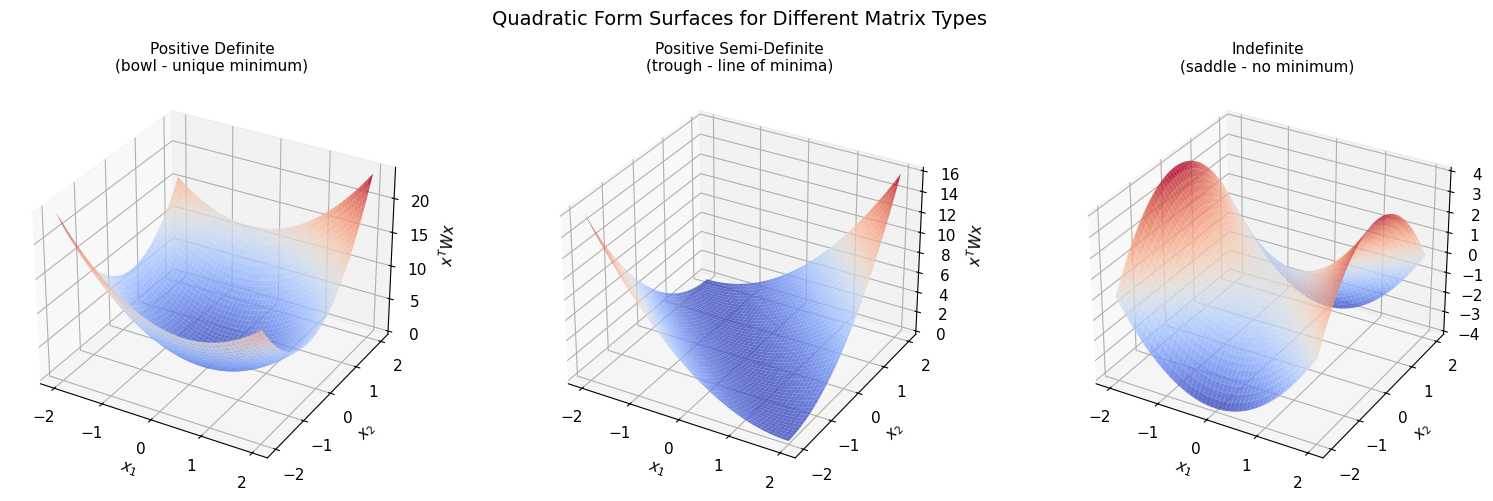

In [23]:
# Visualize as 3D surfaces
fig = plt.figure(figsize=(16, 5))

x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)

matrices = [
    (W_pos_def, 'Positive Definite\n(bowl - unique minimum)'),
    (W_pos_semi, 'Positive Semi-Definite\n(trough - line of minima)'),
    (W_indefinite, 'Indefinite\n(saddle - no minimum)')
]

for idx, (W, title) in enumerate(matrices):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            v = np.array([X[i,j], Y[i,j]])
            Z[i,j] = v @ W @ v
    
    ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.8, linewidth=0)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_zlabel('$x^T W x$')
    ax.set_title(title, fontsize=11)

plt.suptitle('Quadratic Form Surfaces for Different Matrix Types', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. The Gradient of a Quadratic Form

An important property:

$$\nabla_\mathbf{x} (\mathbf{x}^T \mathbf{W} \mathbf{x}) = (\mathbf{W} + \mathbf{W}^T) \mathbf{x} = 2\mathbf{W}\mathbf{x} \quad \text{(if } \mathbf{W} \text{ is symmetric)}$$

Setting this to zero gives $\mathbf{W}\mathbf{x} = 0$, which means $\mathbf{x} = 0$ is the only critical point (for positive definite $\mathbf{W}$).

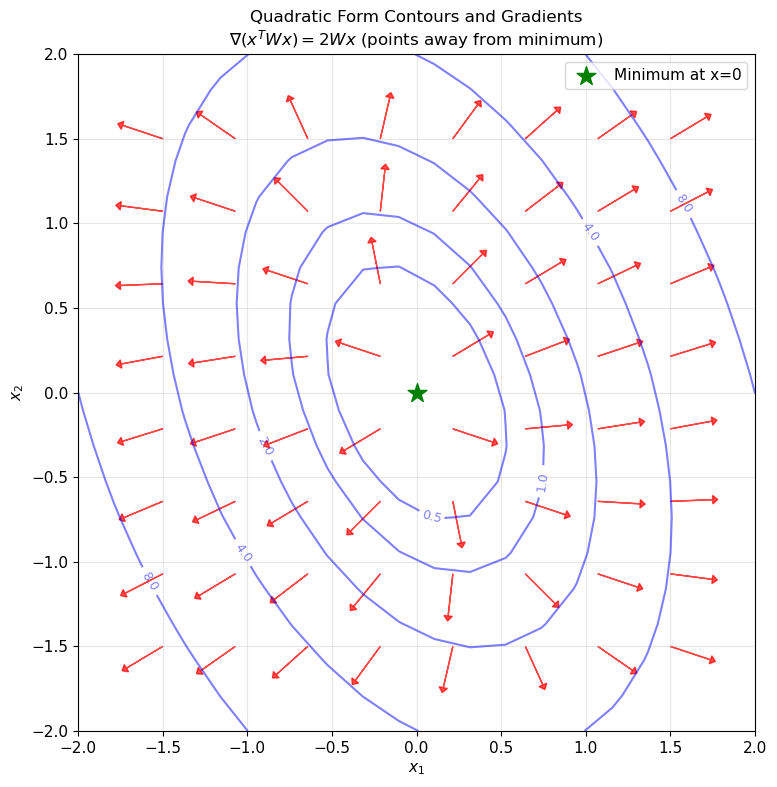

In [24]:
# Visualize gradient vectors for a quadratic form
W = np.array([[2, 0.5], [0.5, 1]])

fig, ax = plt.subplots(figsize=(10, 8))

# Create grid
x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(x, y)

# Compute quadratic form values for contours
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        v = np.array([X[i,j], Y[i,j]])
        Z[i,j] = v @ W @ v

# Plot contours
levels = [0.5, 1, 2, 4, 8]
cs = ax.contour(X, Y, Z, levels=levels, colors='blue', alpha=0.5)
ax.clabel(cs, inline=True, fontsize=9)

# Compute and plot gradient vectors at sparse points
x_sparse = np.linspace(-1.5, 1.5, 8)
y_sparse = np.linspace(-1.5, 1.5, 8)
X_s, Y_s = np.meshgrid(x_sparse, y_sparse)

for i in range(X_s.shape[0]):
    for j in range(X_s.shape[1]):
        if abs(X_s[i,j]) < 0.1 and abs(Y_s[i,j]) < 0.1:
            continue  # Skip origin
        v = np.array([X_s[i,j], Y_s[i,j]])
        grad = 2 * W @ v  # Gradient
        # Normalize for visualization
        grad_norm = grad / np.linalg.norm(grad) * 0.25
        ax.arrow(v[0], v[1], grad_norm[0], grad_norm[1], 
                head_width=0.05, head_length=0.03, fc='red', ec='red', alpha=0.7)

ax.scatter([0], [0], c='green', s=200, marker='*', zorder=5, label='Minimum at x=0')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Quadratic Form Contours and Gradients\n$\\nabla(x^T W x) = 2Wx$ (points away from minimum)', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

---
## 5. Diagonalization: Understanding the Shape

For a symmetric matrix, we can diagonalize:

$$\mathbf{W} = \mathbf{Q} \mathbf{\Lambda} \mathbf{Q}^T$$

Then:
$$\mathbf{x}^T \mathbf{W} \mathbf{x} = \mathbf{x}^T \mathbf{Q} \mathbf{\Lambda} \mathbf{Q}^T \mathbf{x} = \mathbf{z}^T \mathbf{\Lambda} \mathbf{z} = \sum_i \lambda_i z_i^2$$

where $\mathbf{z} = \mathbf{Q}^T \mathbf{x}$ (rotated coordinates).

**Insight**: In the eigenvector basis, the quadratic form is just a weighted sum of squares!

In [25]:
# Diagonalization example
W = np.array([[5, 2], [2, 2]])

# Eigendecomposition
eigenvalues, Q = np.linalg.eigh(W)
Lambda = np.diag(eigenvalues)

print("Diagonalization: W = Q Λ Q.T")
print("="*50)
print(f"\nW = ")
print(W)
print(f"\nEigenvalues (Λ diagonal): {eigenvalues.round(3)}")
print(f"\nEigenvectors (Q columns):")
print(Q.round(3))

# Verify
W_reconstructed = Q @ Lambda @ Q.T
print(f"\nVerify Q Λ Q.T = W: {np.allclose(W, W_reconstructed)}")

Diagonalization: W = Q Λ Q.T

W = 
[[5 2]
 [2 2]]

Eigenvalues (Λ diagonal): [1. 6.]

Eigenvectors (Q columns):
[[ 0.447 -0.894]
 [-0.894 -0.447]]

Verify Q Λ Q.T = W: True


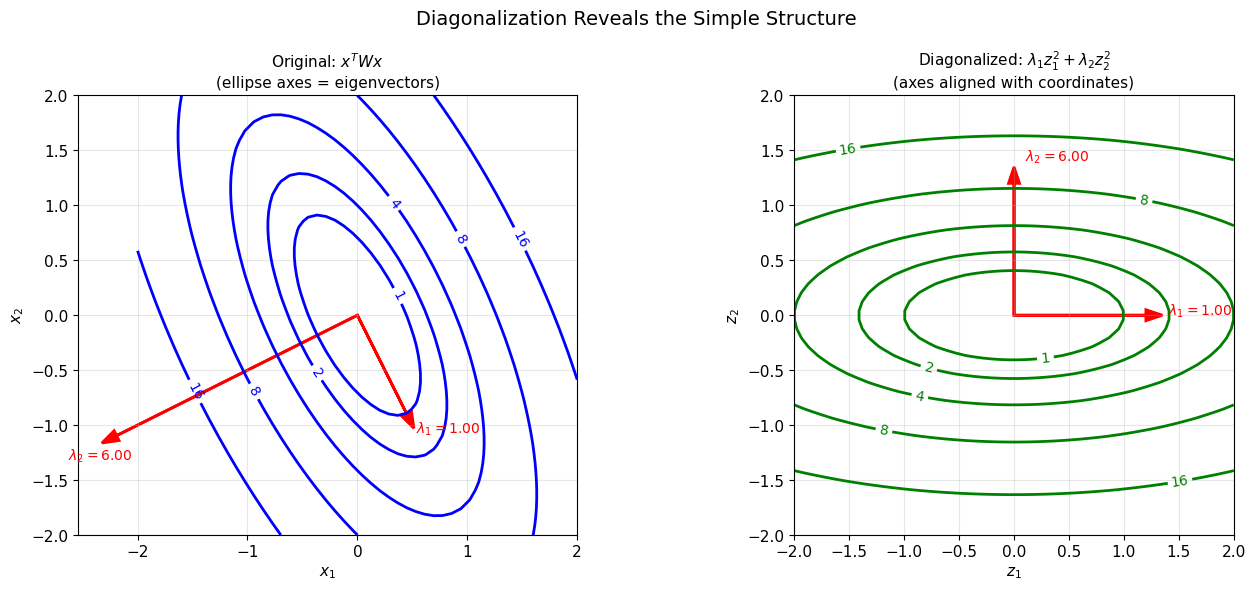

In [26]:
# Visualize: original vs diagonalized view
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)

# Original coordinates
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        v = np.array([X[i,j], Y[i,j]])
        Z[i,j] = v @ W @ v

ax1 = axes[0]
cs1 = ax1.contour(X, Y, Z, levels=[1, 2, 4, 8, 16], colors='blue', linewidths=2)
ax1.clabel(cs1, inline=True, fontsize=10)
# Draw eigenvectors
for i in range(2):
    ev = Q[:, i] * np.sqrt(eigenvalues[i])
    ax1.arrow(0, 0, ev[0], ev[1], head_width=0.1, fc='red', ec='red', linewidth=2)
    ax1.text(ev[0]*1.2, ev[1]*1.2, f'$\\lambda_{i+1}={eigenvalues[i]:.2f}$', fontsize=10, color='red')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_title('Original: $x^T W x$\n(ellipse axes = eigenvectors)', fontsize=11)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# Rotated coordinates (diagonalized)
Z_diag = eigenvalues[0] * X**2 + eigenvalues[1] * Y**2
ax2 = axes[1]
cs2 = ax2.contour(X, Y, Z_diag, levels=[1, 2, 4, 8, 16], colors='green', linewidths=2)
ax2.clabel(cs2, inline=True, fontsize=10)
ax2.arrow(0, 0, 1.2, 0, head_width=0.1, fc='red', ec='red', linewidth=2)
ax2.arrow(0, 0, 0, 1.2, head_width=0.1, fc='red', ec='red', linewidth=2)
ax2.text(1.4, 0, f'$\\lambda_1={eigenvalues[0]:.2f}$', fontsize=10, color='red')
ax2.text(0.1, 1.4, f'$\\lambda_2={eigenvalues[1]:.2f}$', fontsize=10, color='red')
ax2.set_xlabel('$z_1$')
ax2.set_ylabel('$z_2$')
ax2.set_title('Diagonalized: $\\lambda_1 z_1^2 + \\lambda_2 z_2^2$\n(axes aligned with coordinates)', fontsize=11)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.suptitle('Diagonalization Reveals the Simple Structure', fontsize=14)
plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **Quadratic form** $\mathbf{x}^T \mathbf{W} \mathbf{x}$ maps a vector to a scalar
   - It's a weighted, potentially correlated "distance" measure

2. **Special cases**:
   - $\mathbf{W} = \mathbf{I}$: squared Euclidean norm
   - $\mathbf{W} = \mathbf{\Sigma}^{-1}$: squared Mahalanobis distance

3. **Matrix type determines shape**:
   - Positive definite: bowl (has minimum)
   - Positive semi-definite: trough (flat direction)
   - Indefinite: saddle (no minimum)

4. **Eigenvalues reveal structure**: In the eigenbasis, it's just $\sum_i \lambda_i z_i^2$

5. **Applications**: Outlier detection, Gaussian distributions, portfolio risk, optimization

**Next**: We'll explore the $\mathbf{A} \mathbf{B} \mathbf{A}^T$ pattern — how linear transformations affect covariance matrices.